In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from src.data_loader import load_data, remove_nulls,show_duplicates,fill_nulls
from src.analysis import calculate_ema,calculate_sma,calculate_rsi,identify_rsi_signals,calculate_macd,calculate_macd_last_2_years



# LOAD DATA

In [2]:
df = load_data("../data/raw/Data/AAPL.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


#  DATA PREPARATION

In [3]:

# 1. Normalize timestamps (convert to timezone-naive)
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# make timezone-naive
df['Date'] = df['Date'].dt.tz_localize(None)

# verify
print(df['Date'].head())

# 2. Ensure columns are correctly typed
df = df.astype({'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'float64'})

0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[us]


# HANDLE MISSING VALUES


In [4]:
df = fill_nulls(df)
df = remove_nulls(df)
df.head()

No missing values found.


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No missing values found. All 3774 rows kept.


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08


# Technical Indicators with TA-Lib

In [5]:
df = df.sort_values('Date')
df = calculate_sma(
    df,
    column='Close',
    windows=[20,50,100]
)

# calculate EMA
df = calculate_ema(
    df,
    column='Close',
    windows=[20,50,100]
)

# display results
print(df.tail(20))

           Date       Close        High         Low        Open       Volume  \
3754 2023-12-01  189.450836  189.767835  187.459631  188.549346   45704800.0   
3755 2023-12-04  187.657761  188.271970  185.696289  188.202618   43389500.0   
3756 2023-12-05  191.610458  192.581286  188.400765  188.430498   66628400.0   
3757 2023-12-06  190.520752  192.937912  190.312710  192.630814   41089700.0   
3758 2023-12-07  192.452499  193.175666  191.778853  191.818488   47477700.0   
3759 2023-12-08  193.879013  194.156392  191.858090  192.383130   53406400.0   
3760 2023-12-11  191.372681  191.679793  189.629152  191.303343   60943700.0   
3761 2023-12-12  192.888382  192.898283  189.926350  191.273627   52696900.0   
3762 2023-12-13  196.107956  196.147575  193.027051  193.264796   70404200.0   
3763 2023-12-14  196.256592  197.752460  194.324838  196.167437   66831600.0   
3764 2023-12-15  195.721619  196.543840  195.156944  195.681984  128538400.0   
3765 2023-12-18  194.057343  194.790425 

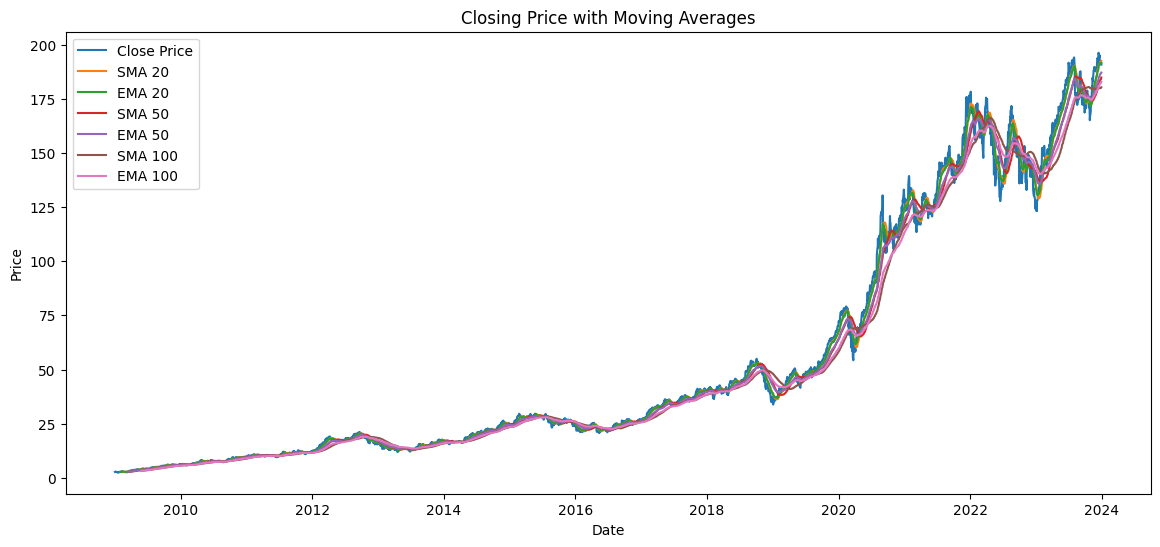

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Close Price')

plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')
plt.plot(df['Date'], df['SMA_50'], label='SMA 50')
plt.plot(df['Date'], df['EMA_50'], label='EMA 50')
plt.plot(df['Date'], df['SMA_100'], label='SMA 100')
plt.plot(df['Date'], df['EMA_100'], label='EMA 100')
plt.xlabel("Date")
plt.ylabel("Price")

plt.title("Closing Price with Moving Averages")

plt.legend()

plt.show()

### Moving Average Analysis Summary

- The stock showed a strong long-term upward trend, especially after 2019.
- SMA and EMA closely followed the closing price, confirming the overall market direction.
- EMA reacted more quickly to short-term price fluctuations, while SMA appeared smoother and lagged slightly behind price movements.
- Periods where moving averages moved sharply upward reflected strong bullish momentum and increased market activity.
- Higher volatility was observed between 2020 and 2023, with larger price swings and rapid trend changes.

### Relative Strength Index(RSI)

In [7]:
df = calculate_rsi(
    df,
    column='Close',
    period=14
)

In [8]:



df = identify_rsi_signals(df)

print(
    df[
        ['Date', 'Close', 'RSI', 'Overbought', 'Oversold']
    ].tail(20)
)

           Date       Close        RSI  Overbought  Oversold
3754 2023-12-01  189.450836  67.590969       False     False
3755 2023-12-04  187.657761  61.089423       False     False
3756 2023-12-05  191.610458  68.322981       False     False
3757 2023-12-06  190.520752  64.749267       False     False
3758 2023-12-07  192.452499  67.949713       False     False
3759 2023-12-08  193.879013  70.107992        True     False
3760 2023-12-11  191.372681  62.184684       False     False
3761 2023-12-12  192.888382  64.777206       False     False
3762 2023-12-13  196.107956  69.552269       False     False
3763 2023-12-14  196.256592  69.756115       False     False
3764 2023-12-15  195.721619  67.991716       False     False
3765 2023-12-18  194.057343  62.680148       False     False
3766 2023-12-19  195.097504  64.544428       False     False
3767 2023-12-20  193.007248  58.247457       False     False
3768 2023-12-21  192.858643  57.815603       False     False
3769 2023-12-22  191.788

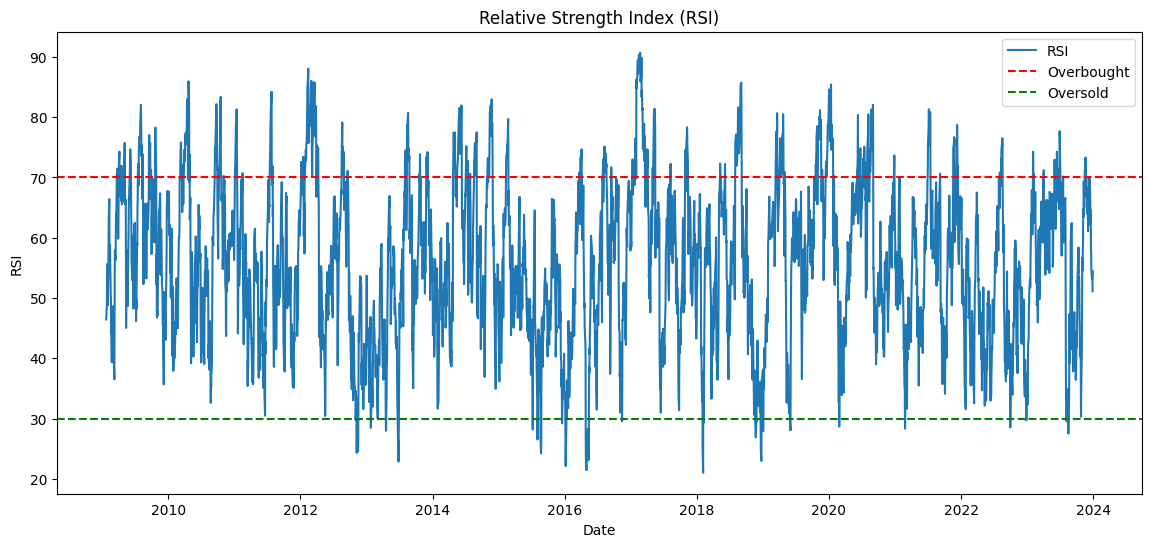

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['RSI'],
    label='RSI'
)

# overbought line
plt.axhline(
    70,
    color='red',
    linestyle='--',
    label='Overbought'
)

# oversold line
plt.axhline(
    30,
    color='green',
    linestyle='--',
    label='Oversold'
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.title("Relative Strength Index (RSI)")

plt.legend()

plt.show()

#### RSI Analysis Summary

- The RSI fluctuated frequently between overbought and oversold levels, indicating changing market momentum over time.
- Several periods crossed above the 70 threshold, suggesting temporary overbought conditions and potential price pullbacks.
- Multiple dips below the 30 threshold indicated oversold conditions, which may signal possible buying opportunities or price rebounds.
- Most RSI values remained within the neutral range (30–70), reflecting normal market trading behavior during much of the period.

### MACD (Moving Average Convergence Divergence)


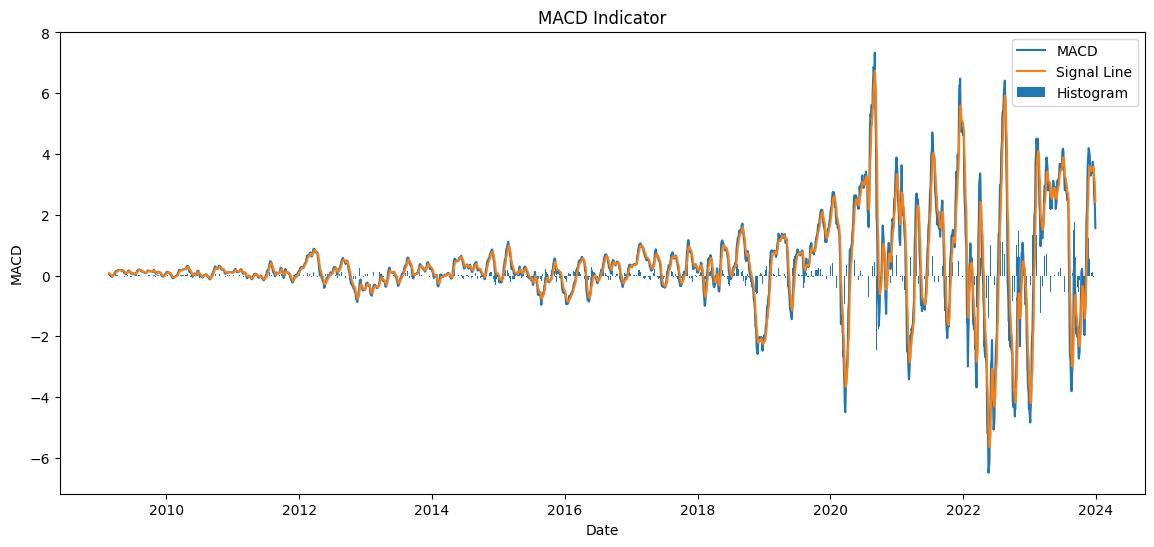

In [10]:
# calculate MACD
df = calculate_macd(df)
plt.figure(figsize=(14,6))

# MACD line
plt.plot(
    df['Date'],
    df['MACD'],
    label='MACD'
)

# Signal line
plt.plot(
    df['Date'],
    df['MACD_Signal'],
    label='Signal Line'
)

# Histogram
plt.bar(
    df['Date'],
    df['MACD_Histogram'],
    label='Histogram'
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.title("MACD Indicator")

plt.legend()

plt.show()

#### MACD Analysis Summary

- The MACD showed several changes between upward and downward market momentum over time.
- Market movements became more volatile after 2020, with larger price swings and stronger trends.
- Positive histogram values indicated upward momentum, while negative values showed downward momentum.
- Crossovers between the MACD and signal line suggested possible trend changes and trading signals.

#### MACD For The Last 2 Years

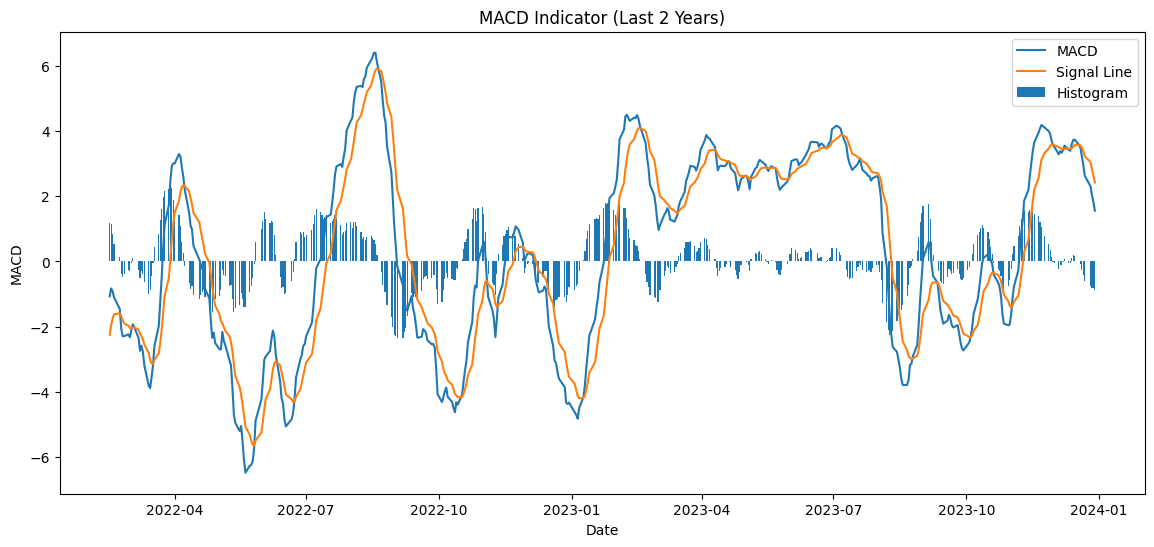

In [11]:
# calculate MACD for last 2 years
macd_df = calculate_macd_last_2_years(df)
plt.figure(figsize=(14,6))

# MACD line
plt.plot(
    macd_df['Date'],
    macd_df['MACD'],
    label='MACD'
)

# Signal line
plt.plot(
    macd_df['Date'],
    macd_df['MACD_Signal'],
    label='Signal Line'
)

# Histogram
plt.bar(
    macd_df['Date'],
    macd_df['MACD_Histogram'],
    label='Histogram'
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.title("MACD Indicator (Last 2 Years)")

plt.legend()

plt.show()

#### MACD Comparison Summary

- The 2-year MACD chart shows recent market movements more clearly than the full historical chart.
- Several crossings between the MACD and signal line show frequent changes between upward and downward trends.
- Strong upward momentum appeared during parts of 2022 and 2023, while some periods showed clear downward pressure.
- Compared to the previous chart, the shorter timeframe makes recent market trends and momentum changes easier to see.